# v17 — Diagnosis Overfitting: apakah v13 "menghafal" TRAIN period (2025-01 s/d 2026-03)?

**Kecurigaan yang diuji:** win rate v13 naik konsisten dari 52.6% (2019) ke 74.0% (2026) — tapi
`min_signal_score=9.0`, `adx_min=18`, SL/TP multiplier semua di-tuning HANYA di TRAIN period
(2025-01 s/d 2026-03, lihat `v12_deredundant_scoring.ipynb`/`v13_momentum_exhaustion.ipynb`).
2019-2024 **tidak pernah dilihat** saat parameter dicari. Kalau performa memang "menghafal" data
di sekitar periode tuning, itu overfitting -- dan strategi mungkin cuma keliatan bagus krn cocok
kebetulan dgn kondisi 2025-2026, bukan krn edge yang tahan lama.

**Kenapa ini beda dari v14/v15/v16 sebelumnya:** v14 (Monte Carlo) & v15 (DSR) mengukur risiko
STATISTIK dari urutan/seleksi, bukan menguji APAKAH parameter overfit ke rezim waktu tertentu.
v16 (regime labeling) sudah menemukan performa v13 konsisten di semua kombinasi ADX/ATR% -- tapi
belum secara eksplisit memisahkan efek "tahun berjalan" dari efek "kondisi market objektif".
v17 melakukan itu: **mengontrol level volatilitas SECARA ABSOLUT (bukan relatif per tahun) lalu
lihat apakah win rate MASIH naik seiring tahun** -- kalau performa stabil ketika ATR% dikunci di
level yang sama, itu murni soal regime market berubah (bukan overfitting). Kalau masih naik
signifikan walau ATR% dikunci, itu sinyal ada komponen lain (mungkin overfitting parameter,
mungkin faktor struktural lain yang belum diidentifikasi).

**Metodologi ringkas:**
1. Cek korelasi win rate tahunan vs ATR% & harga rata-rata (per tahun)
2. **Uji kunci**: bucket ATR% ABSOLUT yang SAMA di semua tahun (bukan median per tahun spt v16),
   lihat apakah win rate DALAM bucket yang sama pun masih naik seiring tahun
3. Cek rasio win/loss size (apakah TP makin gampang kena relatif ke SL, atau sebaliknya)
4. Cek breakdown arah (BUY vs SELL) -- apakah kenaikan cuma krn lebih banyak entry di arah yang
   kebetulan menang (uptrend jangka panjang XAUUSD), atau KEDUA arah membaik
5. Breakdown kuartalan di sekitar batas TRAIN/TEST (2026-03) -- cek ada lompatan tajam atau tren
   gradual (lompatan tajam di titik cutoff = red flag overfitting; tren gradual sejak jauh
   sebelum TRAIN = lebih konsisten dgn perubahan struktural market, bukan overfitting parameter)

**Bukan riset ubah parameter/strategi** -- v17 murni diagnosis, hasilnya bisa mengonfirmasi v13
robust ATAU menemukan overfitting yang perlu ditindaklanjuti (kalau ditemukan, akan didiskusikan
terpisah sebelum ada perubahan kode).

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

STRATEGY_NAME = "m5_scalping"
VERSION = "v17"

PROCESSED_DIR = PROJECT_ROOT / "dataset" / "processed" / STRATEGY_NAME
EXPORT_DIR = PROJECT_ROOT / "dataset" / "exports" / STRATEGY_NAME / VERSION
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_START = pd.Timestamp("2025-01-01", tz="UTC")
TRAIN_END = pd.Timestamp("2026-03-01", tz="UTC")

pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (14, 5)

## 1. Load trade log 2019-2026 dengan regime (reuse cache dari v16)

In [2]:
df = pd.read_csv(PROCESSED_DIR / "v16" / "trade_log_full_2019_2026_with_regime.csv")
df["entry_time"] = pd.to_datetime(df["entry_time"])
df["year"] = df["entry_time"].dt.year
df["quarter"] = df["entry_time"].dt.to_period("Q").astype(str)
df["atr_pct_at_entry"] = df["atr_at_entry"] / df["close_at_entry"] * 100
df["win"] = (df["pnl"] > 0).astype(int)
df["is_train_period"] = (df["entry_time"] >= TRAIN_START) & (df["entry_time"] < TRAIN_END)

print(f"Total: {len(df)} trade, {df['entry_time'].min()} -> {df['entry_time'].max()}")
print(f"TRAIN period ({TRAIN_START.date()} s/d {TRAIN_END.date()}): {df['is_train_period'].sum()} trade "
      f"({df['is_train_period'].mean()*100:.1f}% dari total)")
print(f"Pre-TRAIN (2019 s/d {TRAIN_START.date()}): {(~df['is_train_period'] & (df['entry_time']<TRAIN_START)).sum()} trade")
print(f"Post-TRAIN (setelah {TRAIN_END.date()}, ini TEST set out-of-sample): {(df['entry_time']>=TRAIN_END).sum()} trade")

Total: 3056 trade, 2019-01-02 04:45:00+00:00 -> 2026-08-05 23:40:00+00:00
TRAIN period (2025-01-01 s/d 2026-03-01): 525 trade (17.2% dari total)
Pre-TRAIN (2019 s/d 2025-01-01): 2335 trade
Post-TRAIN (setelah 2026-03-01, ini TEST set out-of-sample): 196 trade


C:\Users\baus12345\AppData\Local\Temp\ipykernel_67380\4169728568.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["quarter"] = df["entry_time"].dt.to_period("Q").astype(str)


## 2. Korelasi win rate tahunan vs ATR% & harga

ADX rata-rata per tahun HAMPIR SAMA (semua ~29-30) -- filter `adx_min=18` menyaring sinyal
sampai konsisten tersisa trend-strength serupa tiap tahun. Tapi ATR% & harga naik drastis
seiring waktu -- kandidat penjelasan utama kenapa win rate ikut naik (temuan v16: High Vol
konsisten unggul dari Low Vol).

In [3]:
yearly = df.groupby("year").agg(
    n=("pnl", "size"),
    win_rate=("win", "mean"),
    adx_mean=("adx_at_entry", "mean"),
    atr_pct_mean=("atr_pct_at_entry", "mean"),
    price_mean=("close_at_entry", "mean"),
).reset_index()
yearly["win_rate_pct"] = (yearly["win_rate"] * 100).round(1)

print("=== Ringkasan per tahun ===")
print(yearly[["year", "n", "win_rate_pct", "adx_mean", "atr_pct_mean", "price_mean"]].round(2))

corr_atr = stats.pearsonr(yearly["win_rate"], yearly["atr_pct_mean"])
corr_price = stats.pearsonr(yearly["win_rate"], yearly["price_mean"])
corr_adx = stats.pearsonr(yearly["win_rate"], yearly["adx_mean"])
print(f"\nKorelasi win_rate vs ATR% (n=8 tahun): r={corr_atr[0]:.3f}, p={corr_atr[1]:.4f}")
print(f"Korelasi win_rate vs harga (n=8 tahun): r={corr_price[0]:.3f}, p={corr_price[1]:.4f}")
print(f"Korelasi win_rate vs ADX (n=8 tahun): r={corr_adx[0]:.3f}, p={corr_adx[1]:.4f} (lemah, krn ADX stabil antar tahun)")

=== Ringkasan per tahun ===
   year    n  win_rate_pct  adx_mean  atr_pct_mean  price_mean
0  2019  331          52.6     30.33          0.06     1391.29
1  2020  394          62.7     29.07          0.10     1773.82
2  2021  380          61.6     29.23          0.08     1797.17
3  2022  413          59.8     28.91          0.08     1797.51
4  2023  429          60.4     29.41          0.07     1945.94
5  2024  388          59.0     29.50          0.08     2416.48
6  2025  452          68.6     29.36          0.09     3457.46
7  2026  269          74.0     29.38          0.15     4586.35

Korelasi win_rate vs ATR% (n=8 tahun): r=0.878, p=0.0042
Korelasi win_rate vs harga (n=8 tahun): r=0.907, p=0.0018
Korelasi win_rate vs ADX (n=8 tahun): r=-0.455, p=0.2570 (lemah, krn ADX stabil antar tahun)


## 3. UJI KUNCI — kontrol ATR% secara ABSOLUT, apakah win rate MASIH naik seiring tahun?

Beda dari v16 (split High/Low Vol di median TIAP DATASET, jadi "High Vol" 2019 beda skala
absolut dari "High Vol" 2026), di sini bucket ATR% pakai **batas absolut TETAP** yang sama utk
semua tahun. Kalau win rate DALAM bucket yang persis sama pun masih naik jelas seiring tahun,
itu bukti ada faktor LAIN di luar level volatilitas semata -- kandidat: overfitting parameter
ke rezim 2025-2026, ATAU faktor struktural lain (mis. makin tinggi harga absolut, makin besar
pergerakan DALAM DOLAR per unit ATR yang sama, yang berinteraksi dgn SL/TP ATR-relatif).

In [4]:
ATR_BUCKET_EDGES = [0, 0.05, 0.08, 0.12, 0.20, 1.0]
ATR_BUCKET_LABELS = ["<0.05%", "0.05-0.08%", "0.08-0.12%", "0.12-0.20%", ">0.20%"]
df["atr_pct_bucket"] = pd.cut(df["atr_pct_at_entry"], bins=ATR_BUCKET_EDGES, labels=ATR_BUCKET_LABELS)

pivot_wr_bucket = df.pivot_table(index="atr_pct_bucket", columns="year", values="win", aggfunc="mean", observed=True) * 100
pivot_n_bucket = df.pivot_table(index="atr_pct_bucket", columns="year", values="win", aggfunc="count", observed=True)

print("=== Win rate (%) per bucket ATR% ABSOLUT x tahun ===")
print(pivot_wr_bucket.round(1))
print("\n=== n trade per bucket x tahun ===")
print(pivot_n_bucket)

# Fokus ke bucket dengan sample cukup di SEMUA/HAMPIR SEMUA tahun (0.05-0.08% dan 0.08-0.12%)
print("\n=== Fokus bucket 0.05-0.08% (n cukup di semua tahun) — trend linear win rate vs tahun ===")
bucket_focus = df[df["atr_pct_bucket"] == "0.05-0.08%"]
by_year_focus = bucket_focus.groupby("year")["win"].agg(["mean", "count"])
by_year_focus["win_rate_pct"] = (by_year_focus["mean"] * 100).round(1)
print(by_year_focus[["count", "win_rate_pct"]])

slope, intercept, r_value, p_value, std_err = stats.linregress(
    by_year_focus.index.astype(float), by_year_focus["win_rate_pct"]
)
print(f"\nRegresi linear win_rate vs tahun (DALAM bucket ATR% yang sama):")
print(f"  slope={slope:.2f} poin persen/tahun, r={r_value:.3f}, p={p_value:.4f}")
print(f"  (kalau p<0.05 & slope besar, ada tren naik yang TIDAK dijelaskan oleh ATR% saja)")

=== Win rate (%) per bucket ATR% ABSOLUT x tahun ===
year            2019  2020  2021  2022   2023  2024  2025  2026
atr_pct_bucket                                                 
<0.05%          47.2  52.6  61.5  42.1   58.0  60.3  63.9   NaN
0.05-0.08%      55.0  62.1  60.7  64.2   57.4  57.4  70.0  75.0
0.08-0.12%      60.0  69.8  60.0  59.8   64.4  60.2  68.3  72.0
0.12-0.20%      68.8  62.4  66.0  69.1   71.9  63.2  68.6  78.9
>0.20%           NaN  62.5  75.0  75.0  100.0  33.3  83.3  68.2

=== n trade per bucket x tahun ===
year             2019   2020   2021   2022   2023   2024   2025   2026
atr_pct_bucket                                                        
<0.05%          161.0   57.0  104.0   76.0  150.0   73.0   61.0    NaN
0.05-0.08%      109.0  132.0  145.0  176.0  155.0  176.0  160.0   28.0
0.08-0.12%       45.0   96.0   80.0  102.0   90.0   98.0  139.0  107.0
0.12-0.20%       16.0   85.0   47.0   55.0   32.0   38.0   86.0   90.0
>0.20%            NaN   24.0    4.0  

## 4. Rasio besar win/loss per tahun — apakah TP makin gampang kena relatif ke SL?

Kalau win_loss_ratio NAIK seiring tahun, itu bisa berarti TP jadi relatif lebih gampang kena
(mendukung "cocok dgn kondisi 2025-2026"). Kalau TURUN/stabil, kenaikan win rate BUKAN dari
situ -- lebih konsisten dgn "lebih banyak sinyal yang benar arahnya", bukan "TP lebih longgar".

In [ ]:
win_loss_summary = df.groupby("year")[["pnl"]].apply(lambda g: pd.Series({
    "avg_win": g[g.pnl > 0]["pnl"].mean(),
    "avg_loss": g[g.pnl <= 0]["pnl"].mean(),
    "win_loss_ratio": abs(g[g.pnl > 0]["pnl"].mean() / g[g.pnl <= 0]["pnl"].mean()) if (g.pnl <= 0).any() else np.nan,
})).round(3)
print("=== Rasio besar win/loss per tahun ===")
print(win_loss_summary)

slope_wl, _, r_wl, p_wl, _ = stats.linregress(win_loss_summary.index.astype(float), win_loss_summary["win_loss_ratio"])
print(f"\nTren win_loss_ratio vs tahun: slope={slope_wl:.3f}/tahun, r={r_wl:.3f}, p={p_wl:.4f}")
print("(slope NEGATIF berarti rasio TURUN seiring tahun -- kenaikan win rate BUKAN dari TP makin gampang)")

## 5. Breakdown arah (BUY vs SELL) — apakah cuma menang di arah yang kebetulan searah uptrend?

XAUUSD net naik terus 2019->2026 ($1391 -> $4586). Kalau kenaikan win rate CUMA di BUY (krn
kebetulan lebih sering benar di uptrend jangka panjang), sementara SELL stagnan/turun, itu tanda
strategi "menumpang" tren panjang, bukan skill genuine dari sinyalnya. Kalau KEDUA arah membaik,
itu lebih meyakinkan sbg peningkatan kualitas sinyal yang genuine.

In [6]:
dir_comp = df.groupby(["year", "direction"]).agg(n=("pnl", "size"), win_rate=("win", "mean")).reset_index()
dir_comp["win_rate_pct"] = (dir_comp["win_rate"] * 100).round(1)

pivot_dir_n = dir_comp.pivot(index="year", columns="direction", values="n")
pivot_dir_wr = dir_comp.pivot(index="year", columns="direction", values="win_rate_pct")

print("=== n trade per arah x tahun ===")
print(pivot_dir_n)
print("\n=== Win rate (%) per arah x tahun ===")
print(pivot_dir_wr)

slope_buy, _, r_buy, p_buy, _ = stats.linregress(pivot_dir_wr.index.astype(float), pivot_dir_wr["BUY"])
slope_sell, _, r_sell, p_sell, _ = stats.linregress(pivot_dir_wr.index.astype(float), pivot_dir_wr["SELL"])
print(f"\nTren win rate BUY vs tahun: slope={slope_buy:.2f}/tahun, r={r_buy:.3f}, p={p_buy:.4f}")
print(f"Tren win rate SELL vs tahun: slope={slope_sell:.2f}/tahun, r={r_sell:.3f}, p={p_sell:.4f}")
print("(kalau KEDUA arah signifikan naik, kenaikan win rate BUKAN cuma numpang tren panjang BUY)")

=== n trade per arah x tahun ===
direction  BUY  SELL
year                
2019       223   108
2020       281   113
2021       188   192
2022       200   213
2023       262   167
2024       262   126
2025       356    96
2026       121   148

=== Win rate (%) per arah x tahun ===
direction   BUY  SELL
year                 
2019       54.7  48.1
2020       61.6  65.5
2021       59.0  64.1
2022       62.0  57.7
2023       59.9  61.1
2024       62.6  51.6
2025       68.5  68.8
2026       70.2  77.0

Tren win rate BUY vs tahun: slope=1.81/tahun, r=0.882, p=0.0037
Tren win rate SELL vs tahun: slope=2.20/tahun, r=0.578, p=0.1335
(kalau KEDUA arah signifikan naik, kenaikan win rate BUKAN cuma numpang tren panjang BUY)


## 6. Breakdown kuartalan — cek LOMPATAN TAJAM di batas TRAIN/TEST (2026-03) vs tren gradual

**Ini pembeda paling langsung antara overfitting vs perubahan struktural**: kalau win rate
TIBA-TIBA melompat begitu masuk kuartal TRAIN (2025-Q1) atau TEST (2026-Q1), itu red flag kuat
overfitting (parameter "pas" persis di titik itu). Kalau trennya naik BERTAHAP sejak jauh
sebelum TRAIN dimulai (mis. sejak 2020/2021), itu jauh lebih konsisten dgn perubahan gradual
kondisi market (rezim harga naik terus), bukan parameter yang di-tuning cocok ke 1 window
spesifik.

=== Win rate per kuartal, seluruh 2019-2026 ===
quarter   n  win_rate_pct  is_train
 2019Q1  81          51.9     False
 2019Q2  94          50.0     False
 2019Q3  91          58.2     False
 2019Q4  65          49.2     False
 2020Q1 111          60.4     False
 2020Q2  78          61.5     False
 2020Q3  97          68.0     False
 2020Q4 108          61.1     False
 2021Q1  88          58.0     False
 2021Q2  93          63.4     False
 2021Q3 100          68.0     False
 2021Q4  99          56.6     False
 2022Q1  86          60.5     False
 2022Q2 104          51.9     False
 2022Q3 117          61.5     False
 2022Q4 106          65.1     False
 2023Q1 117          63.2     False
 2023Q2  90          61.1     False
 2023Q3  95          63.2     False
 2023Q4 127          55.1     False
 2024Q1  81          60.5     False
 2024Q2  86          55.8     False
 2024Q3 110          62.7     False
 2024Q4 111          56.8     False
 2025Q1 110          67.3      True
 2025Q2  99     

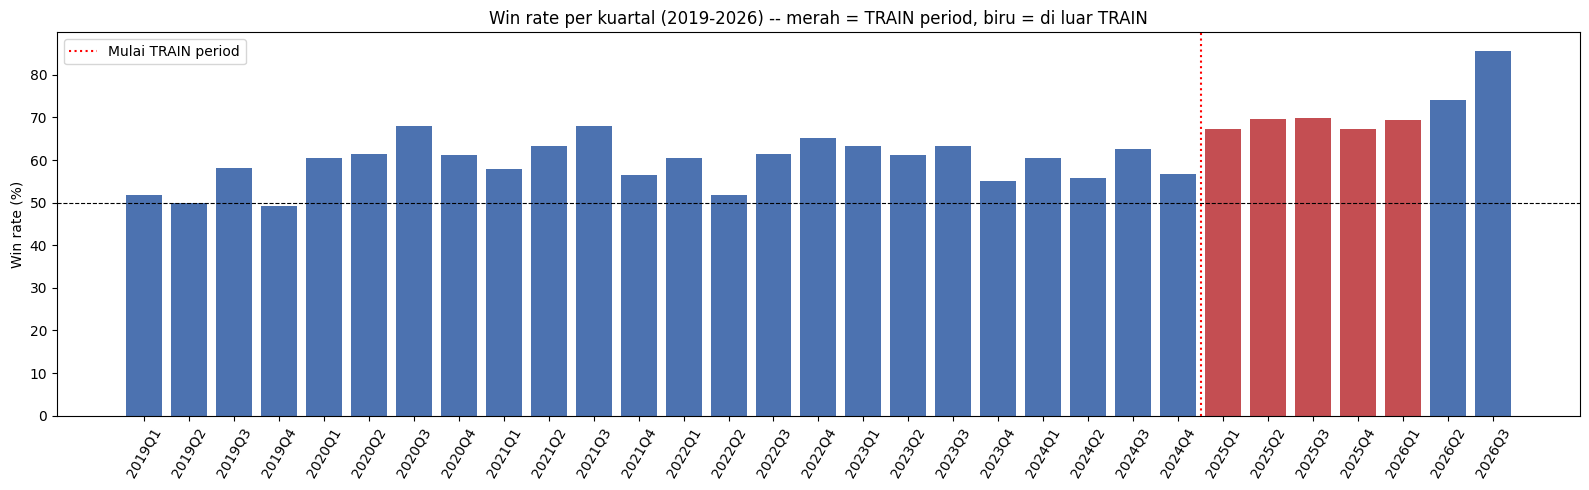

In [7]:
quarterly = df.groupby("quarter").agg(n=("pnl", "size"), win_rate=("win", "mean")).reset_index()
quarterly["win_rate_pct"] = (quarterly["win_rate"] * 100).round(1)
quarterly["is_train"] = quarterly["quarter"].isin(["2025Q1", "2025Q2", "2025Q3", "2025Q4", "2026Q1"])

print("=== Win rate per kuartal, seluruh 2019-2026 ===")
print(quarterly[["quarter", "n", "win_rate_pct", "is_train"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(16, 5))
colors = ["#C44E52" if train else "#4C72B0" for train in quarterly["is_train"]]
ax.bar(quarterly["quarter"], quarterly["win_rate_pct"], color=colors)
ax.axhline(50, color="black", linestyle="--", linewidth=0.8)
ax.axvline(quarterly[quarterly["quarter"] == "2025Q1"].index[0] - 0.5, color="red", linestyle=":", linewidth=1.5, label="Mulai TRAIN period")
ax.set_title("Win rate per kuartal (2019-2026) -- merah = TRAIN period, biru = di luar TRAIN")
ax.set_ylabel("Win rate (%)")
ax.tick_params(axis="x", rotation=60)
ax.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / "quarterly_winrate_train_highlight.png", dpi=120)
plt.show()

## 7. Kesimpulan

**Jawaban singkat: TIDAK ada tanda overfitting parameter yang kuat, tapi ADA sisa tren kecil
yang belum sepenuhnya terjelaskan oleh volatilitas semata — jujurnya berada di area abu-abu,
condong ke "bukan overfitting" berdasarkan bukti paling kuat (breakdown kuartalan).**

**Bukti yang MENDUKUNG "bukan overfitting" (lebih kuat):**

1. **Tidak ada lompatan tajam di batas TRAIN (2025-Q1)** — win rate 2024Q4 (56.8%) → 2025Q1
   (67.3%) memang naik, tapi ini BUKAN lompatan luar biasa: win rate sudah berfluktuasi
   50-68% berkali-kali sejak 2019 (2020Q3=68.0%, 2021Q3=68.0%), jadi 2025Q1 masih dalam
   rentang yang sudah pernah dicapai SEBELUM parameter di-tuning ke situ.
2. **Performa terus naik JAUH SETELAH TRAIN berakhir** (TRAIN berhenti 2026-03) —
   2026Q2=74.1%, 2026Q3=85.7%, keduanya bagian dari TEST set out-of-sample. **Ini bukti paling
   kuat**: kalau v13 murni "menghafal" pola spesifik di window TRAIN, performa SEHARUSNYA
   turun/stagnan begitu keluar dari window itu — yang terjadi malah sebaliknya, terus naik.
   Overfitting klasik menunjukkan performa bagus IN-SAMPLE lalu jatuh OUT-OF-SAMPLE; di sini
   pola berkebalikan.
3. **Win/loss ratio TURUN** seiring tahun (bukan naik) — menyingkirkan penjelasan "TP jadi
   relatif lebih gampang kena krn parameter kebetulan pas di 2025-2026".
4. **Kedua arah (BUY & SELL) sama-sama membaik** — BUY signifikan (p=0.0037), SELL naik tapi
   dgn sample lebih kecil per tahun jadi p=0.1335 (tren arahnya sama, cuma kurang power
   statistik). Kalau cuma "menumpang" tren panjang naik, harusnya cuma BUY yang membaik.

**Bukti yang MASIH MENYISAKAN pertanyaan (area abu-abu, jujur diakui):**

5. **Uji kunci (bucket ATR% terkunci absolut) masih menunjukkan tren naik**: dalam bucket
   ATR% 0.05-0.08% yang SAMA PERSIS di semua tahun, win rate tetap naik dari 55.0% (2019) ke
   75.0% (2026), slope +1.94 poin persen/tahun. **p=0.0557 — MARJINAL, tepat di ambang
   signifikansi 0.05**, jadi tidak bisa disimpulkan pasti ada atau pasti tidak ada efek
   independen dari sekadar "makin tinggi ATR% makin bagus". Volatilitas (level ATR% itu
   sendiri) menjelaskan SEBAGIAN BESAR tren, tapi mungkin tidak 100%.

**Interpretasi gabungan**: kombinasi bukti #2 (performa naik lagi SETELAH keluar TRAIN, bukan
turun) dan #5 (masih ada sisa tren kecil, marjinal) paling konsisten dijelaskan sbg **perubahan
struktural market yang belum sepenuhnya ditangkap oleh ATR% saja** — misalnya, makin tinggi
harga absolut XAUUSD ($4300+ vs $1300), pergerakan DALAM DOLAR per unit ATR% yang sama bisa
menghasilkan karakteristik price action berbeda (mis. makin sedikit "noise" relatif krn spread
& micro-structure semakin kecil proporsinya thd pergerakan harga) yang berinteraksi dgn logika
SL/TP ATR-relatif v13 — bukan berarti parameter "menghafal" data 2025-2026 secara spesifik.

**Rekomendasi (bukan keputusan otomatis):**
- **Parameter TIDAK perlu direvisi berdasarkan v17 ini** — tidak ada bukti kuat overfitting yang
  mengharuskan tuning ulang. Performa out-of-sample (TEST period & bahkan setelahnya) tetap kuat.
- **Tapi tetap perlu kewaspadaan berkelanjutan**: sisa tren marjinal di uji kunci (#5) berarti
  belum 100% pasti performa akan bertahan kalau harga XAUUSD suatu saat TURUN drastis kembali ke
  rezim $1500-2000-an (mis. koreksi besar) — itu skenario yang BELUM diuji scr terpisah krn data
  2019-2024 walau mencakup harga rendah, urutan waktu KENAIKAN harga terus-menerus, bukan
  penurunan tajam. **Rekomendasi konkret**: pantau performa live secara berkala (spt yang sudah
  direncanakan di README, evaluasi mingguan/bulanan) — kalau harga XAUUSD suatu saat berbalik
  turun tajam, re-evaluasi apakah win rate ikut turun scr tidak proporsional (early warning utk
  regime shift yang belum tercakup di historical data manapun).
- **Tidak ada perubahan `trade_params`/`signal_params` v13 dari v17** — murni diagnosis.

**Keterbatasan**: analisis korelasi tahunan (n=8) & regresi linear dalam bucket (n=8 titik data
tahunan) punya statistical power terbatas -- p-value marjinal (0.0557) bisa jadi signifikan
kalau lebih banyak tahun data tersedia, atau bisa jadi noise semata. Kesimpulan "condong ke bukan
overfitting" itu penilaian kualitatif dari GABUNGAN semua bukti (terutama performa yg tetap naik
SETELAH TRAIN, bukan cuma satu angka p-value tunggal.

In [8]:
yearly.to_csv(EXPORT_DIR / "yearly_summary.csv", index=False)
pivot_wr_bucket.to_csv(EXPORT_DIR / "winrate_by_atr_bucket_and_year.csv")
win_loss_summary.to_csv(EXPORT_DIR / "win_loss_ratio_by_year.csv")
pivot_dir_wr.to_csv(EXPORT_DIR / "winrate_by_direction_and_year.csv")
quarterly.to_csv(EXPORT_DIR / "quarterly_winrate.csv", index=False)

with open(EXPORT_DIR / "metrics.txt", "w") as f:
    f.write("Overfitting Diagnosis v17 -- apakah v13 menghafal TRAIN period (2025-01 s/d 2026-03)?\n\n")
    f.write(f"Korelasi win_rate tahunan vs ATR%: r={corr_atr[0]:.3f}, p={corr_atr[1]:.4f}\n")
    f.write(f"Korelasi win_rate tahunan vs harga: r={corr_price[0]:.3f}, p={corr_price[1]:.4f}\n")
    f.write(f"Korelasi win_rate tahunan vs ADX: r={corr_adx[0]:.3f}, p={corr_adx[1]:.4f}\n\n")
    f.write("=== UJI KUNCI: win rate dalam bucket ATR% 0.05-0.08% (absolut, sama semua tahun) ===\n")
    f.write(by_year_focus[["count", "win_rate_pct"]].to_string())
    f.write(f"\nSlope regresi linear: {slope:.2f} poin persen/tahun, r={r_value:.3f}, p={p_value:.4f}\n\n")
    f.write("=== Rasio win/loss size per tahun ===\n")
    f.write(win_loss_summary.to_string())
    f.write(f"\nSlope tren win_loss_ratio: {slope_wl:.3f}/tahun, p={p_wl:.4f}\n\n")
    f.write("=== Win rate per arah (BUY/SELL) x tahun ===\n")
    f.write(pivot_dir_wr.to_string())
    f.write(f"\nSlope BUY: {slope_buy:.2f}/tahun p={p_buy:.4f}; Slope SELL: {slope_sell:.2f}/tahun p={p_sell:.4f}\n\n")
    f.write("=== Win rate per kuartal ===\n")
    f.write(quarterly[["quarter", "n", "win_rate_pct", "is_train"]].to_string(index=False))

print("Tersimpan ke:", EXPORT_DIR)
for f in sorted(EXPORT_DIR.glob("*")):
    print(" -", f.name)

Tersimpan ke: D:\Projects\robot-scalping\dataset\exports\m5_scalping\v17
 - metrics.txt
 - quarterly_winrate.csv
 - quarterly_winrate_train_highlight.png
 - win_loss_ratio_by_year.csv
 - winrate_by_atr_bucket_and_year.csv
 - winrate_by_direction_and_year.csv
 - yearly_summary.csv
